# Students Marks Prediction — Complete Data Science Pipeline
**CS402 — Data Science | Semester Project**

This notebook implements a full data science pipeline on the **Student Performance Factors** dataset:
**Data Collection → Preprocessing → EDA → Model Building → Evaluation → Reporting.**

We solve **two** problems on the same data:
1. **Regression** — predict the exact `Exam_Score` (0–100).
2. **Classification** — predict the letter **Grade** (A/B/C/D/F) derived from the score.

For each task we train **multiple algorithms** and compare them on standard metrics.


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier, GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
os.makedirs("visualizations", exist_ok=True)
os.makedirs("models", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


## 2. Data Collection — Load the Dataset
> **Dataset:** *Student Performance Factors* — Kaggle (`lainguyn123/student-performance-factors`).
> Download `StudentPerformanceFactors.csv` from Kaggle and place it in the `data/` folder.
> The dataset has **6,607 rows × 20 columns** capturing study habits, attendance, family, and school factors.

In [2]:
df = pd.read_csv("data/StudentPerformanceFactors.csv")
print("Shape:", df.shape)
df.head()

Shape: (100, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,39,92,High,Medium,Yes,5,61,Low,Yes,5,Medium,High,Public,Negative,0,No,Postgraduate,Moderate,Female,85
1,29,64,High,Low,No,4,58,High,Yes,7,High,Low,Public,Neutral,1,No,Postgraduate,Near,Female,68
2,15,98,High,High,No,8,56,High,Yes,3,High,Low,Private,Positive,4,Yes,High School,Near,Female,71
3,43,100,High,Low,No,8,77,Low,No,7,Medium,Low,Private,Positive,0,Yes,College,Moderate,Male,85
4,8,87,Low,Low,Yes,7,63,Medium,No,3,Medium,Low,Private,Neutral,6,Yes,Postgraduate,Far,Male,59


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               100 non-null    int64 
 1   Attendance                  100 non-null    int64 
 2   Parental_Involvement        100 non-null    object
 3   Access_to_Resources         100 non-null    object
 4   Extracurricular_Activities  100 non-null    object
 5   Sleep_Hours                 100 non-null    int64 
 6   Previous_Scores             100 non-null    int64 
 7   Motivation_Level            100 non-null    object
 8   Internet_Access             100 non-null    object
 9   Tutoring_Sessions           100 non-null    int64 
 10  Family_Income               100 non-null    object
 11  Teacher_Quality             100 non-null    object
 12  School_Type                 100 non-null    object
 13  Peer_Influence              100 non-null    object


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,100.0,22.03,12.919686,1.0,11.00,22.0,33.25,44.0
Attendance,100.0,81.37,12.861072,60.0,69.50,85.0,92.00,100.0
Sleep_Hours,100.0,6.45,1.876893,4.0,5.00,6.0,8.00,10.0
Previous_Scores,100.0,74.42,14.727957,50.0,61.00,74.0,88.00,99.0
Tutoring_Sessions,100.0,4.30,2.568260,0.0,2.00,4.5,7.00,8.0
Physical_Activity,100.0,2.80,1.927997,0.0,1.00,3.0,4.00,6.0
Exam_Score,100.0,73.06,10.044165,45.0,66.75,72.0,81.00,97.0


## 3. Data Quality Check — Missing Values & Duplicates

In [5]:
print("Duplicate rows:", df.duplicated().sum())
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
missing

Duplicate rows: 0

Columns with missing values:


Series([], dtype: int64)

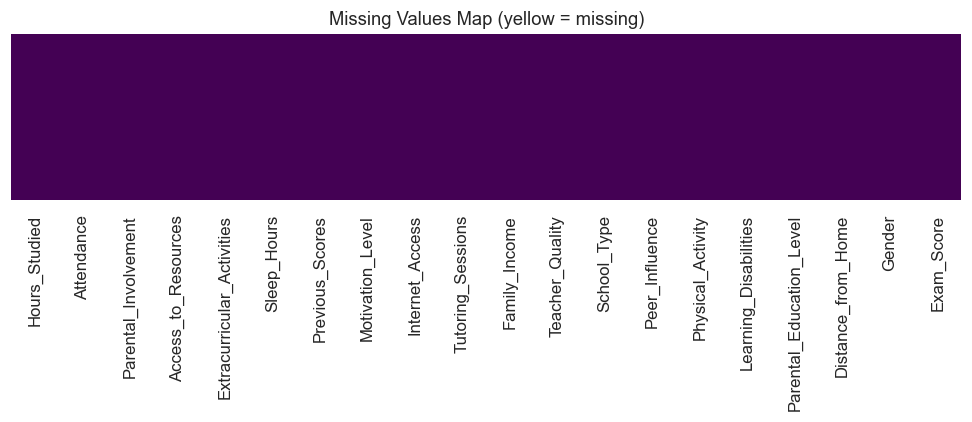

In [6]:
# Visualise missing values
plt.figure(figsize=(9,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Map (yellow = missing)")
plt.tight_layout(); plt.savefig("visualizations/00_missing_values.png", bbox_inches="tight"); plt.show()

## 4. Data Preprocessing
Steps performed:
1. **Missing values** → categorical columns imputed with their **mode**.
2. **Duplicates** → removed.
3. **Outliers** → capped using the **IQR method** on numeric columns.
4. **Feature engineering** → derive `Grade` (A–F) and `Result` (Pass/Fail) from `Exam_Score`.
5. **Encoding** → ordered categories mapped to integers; binary/nominal encoded.
6. **Scaling** → `StandardScaler` applied for distance/linear models.

In [7]:
df_clean = df.copy()

# 1) Impute missing categorical values with mode
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 2) Remove duplicates
before = len(df_clean); df_clean = df_clean.drop_duplicates(); 
print("Removed", before - len(df_clean), "duplicate rows")

# 3) Outlier capping (IQR) on numeric features
num_cols = ["Hours_Studied","Attendance","Sleep_Hours","Previous_Scores",
            "Tutoring_Sessions","Physical_Activity","Exam_Score"]
for col in num_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    df_clean[col] = df_clean[col].clip(lo, hi)

print("Missing after cleaning:", int(df_clean.isnull().sum().sum()))
df_clean.shape

Removed 0 duplicate rows
Missing after cleaning: 0


(100, 20)

In [8]:
# 4) Feature engineering — classification targets from Exam_Score
def to_grade(s):
    if s >= 90: return "A"
    elif s >= 80: return "B"
    elif s >= 70: return "C"
    elif s >= 60: return "D"
    return "F"

df_clean["Grade"]  = df_clean["Exam_Score"].apply(to_grade)
df_clean["Result"] = np.where(df_clean["Exam_Score"] >= 60, "Pass", "Fail")
print(df_clean["Grade"].value_counts().sort_index())
print()
print(df_clean["Result"].value_counts())

Grade
A     6
B    23
C    31
D    34
F     6
Name: count, dtype: int64

Result
Pass    94
Fail     6
Name: count, dtype: int64


In [9]:
# 5) Encoding
df_enc = df_clean.copy()
ordinal_maps = {
    "Parental_Involvement": {"Low":0,"Medium":1,"High":2},
    "Access_to_Resources": {"Low":0,"Medium":1,"High":2},
    "Motivation_Level":    {"Low":0,"Medium":1,"High":2},
    "Family_Income":       {"Low":0,"Medium":1,"High":2},
    "Teacher_Quality":     {"Low":0,"Medium":1,"High":2},
    "Peer_Influence":      {"Negative":0,"Neutral":1,"Positive":2},
    "Distance_from_Home":  {"Near":2,"Moderate":1,"Far":0},
    "Parental_Education_Level": {"High School":0,"College":1,"Postgraduate":2},
}
binary_maps = {
    "Extracurricular_Activities": {"No":0,"Yes":1},
    "Internet_Access":            {"No":0,"Yes":1},
    "Learning_Disabilities":      {"No":1,"Yes":0},   # 'No disability' is the favourable case
    "School_Type":                {"Public":0,"Private":1},
    "Gender":                     {"Male":0,"Female":1},
}
for col, mp in {**ordinal_maps, **binary_maps}.items():
    df_enc[col] = df_enc[col].map(mp)

feature_cols = [c for c in df_enc.columns if c not in ["Exam_Score","Grade","Result"]]
print("Encoded. Features used for modelling:", len(feature_cols))
df_enc[feature_cols].head()

Encoded. Features used for modelling: 19


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,39,92,2,1,1,5,61,0,1,5,1,2,0,0,0,1,2,1,1
1,29,64,2,0,0,4,58,2,1,7,2,0,0,1,1,1,2,2,1
2,15,98,2,2,0,8,56,2,1,3,2,0,1,2,4,0,0,2,1
3,43,100,2,0,0,8,77,0,0,7,1,0,1,2,0,0,1,1,0
4,8,87,0,0,1,7,63,1,0,3,1,0,1,1,6,0,2,0,0


In [10]:
# Save cleaned dataset (human-readable, before encoding)
df_clean.to_csv("data/cleaned_student_data.csv", index=False)
print("Saved -> data/cleaned_student_data.csv", df_clean.shape)

Saved -> data/cleaned_student_data.csv (100, 22)


## 5. Exploratory Data Analysis (EDA)
We produce **12 visualizations**, each followed by an insight. All figures are saved to the `visualizations/` folder.

### 5.1 Distribution of Exam Scores

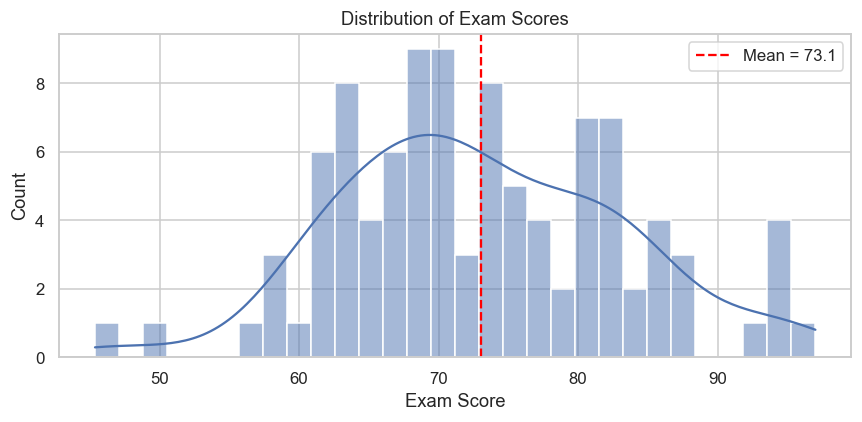

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean["Exam_Score"], kde=True, bins=30, color="#4C72B0")
plt.axvline(df_clean["Exam_Score"].mean(), color="red", ls="--", label=f"Mean = {df_clean['Exam_Score'].mean():.1f}")
plt.title("Distribution of Exam Scores"); plt.xlabel("Exam Score"); plt.legend()
plt.tight_layout(); plt.savefig("visualizations/01_score_distribution.png", bbox_inches="tight"); plt.show()

**Insight:** Scores are roughly bell-shaped and centred near ~75, indicating most students perform moderately well with few extreme low/high scores.

### 5.2 Grade Distribution

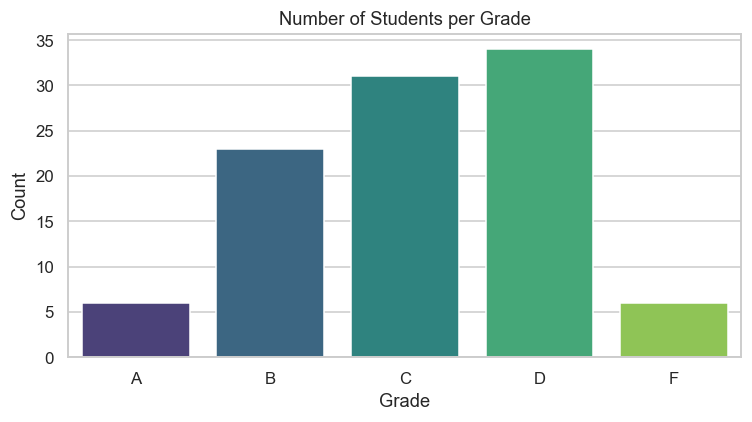

In [12]:
plt.figure(figsize=(7,4))
order = ["A","B","C","D","F"]
sns.countplot(x="Grade", data=df_clean, order=order, palette="viridis")
plt.title("Number of Students per Grade"); plt.xlabel("Grade"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("visualizations/02_grade_distribution.png", bbox_inches="tight"); plt.show()

**Insight:** Grades C and D dominate; very few students reach grade A. This class imbalance is important to remember when reading classification metrics.

### 5.3 Correlation Heatmap (numeric features)

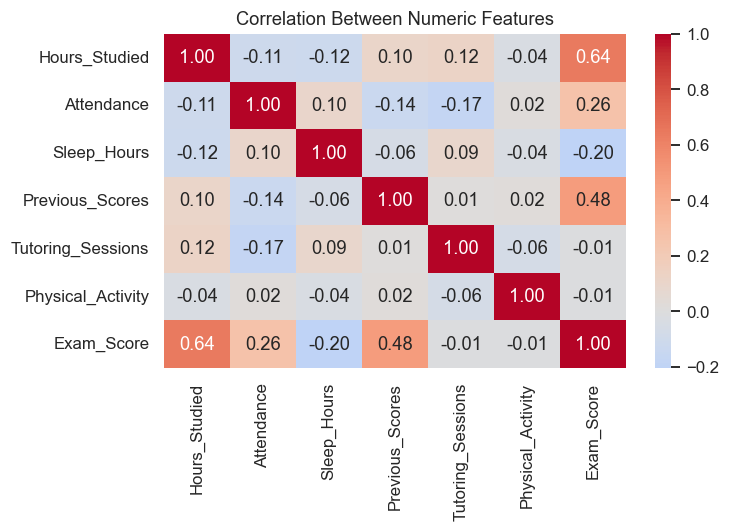

In [13]:
plt.figure(figsize=(7,5))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Features")
plt.tight_layout(); plt.savefig("visualizations/03_correlation_heatmap.png", bbox_inches="tight"); plt.show()

**Insight:** `Hours_Studied` and `Attendance` show the strongest positive correlation with `Exam_Score`, making them the most promising predictors.

### 5.4 Hours Studied vs Exam Score

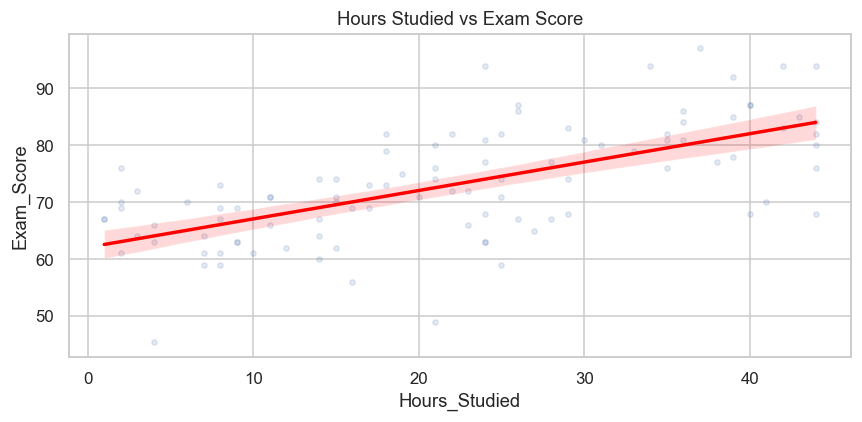

In [14]:
plt.figure(figsize=(8,4))
sns.regplot(x="Hours_Studied", y="Exam_Score", data=df_clean,
            scatter_kws={"alpha":0.15,"s":12}, line_kws={"color":"red"})
plt.title("Hours Studied vs Exam Score")
plt.tight_layout(); plt.savefig("visualizations/04_hours_vs_score.png", bbox_inches="tight"); plt.show()

**Insight:** A clear positive linear trend — more weekly study hours generally translate into higher scores.

### 5.5 Attendance vs Exam Score

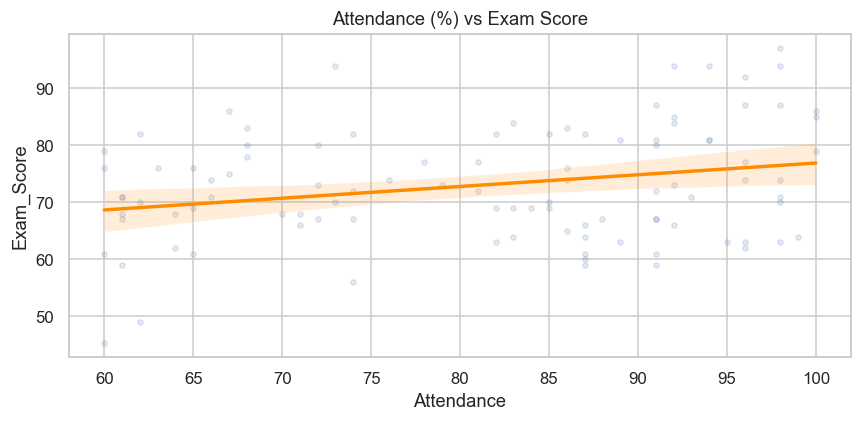

In [15]:
plt.figure(figsize=(8,4))
sns.regplot(x="Attendance", y="Exam_Score", data=df_clean,
            scatter_kws={"alpha":0.15,"s":12}, line_kws={"color":"darkorange"})
plt.title("Attendance (%) vs Exam Score")
plt.tight_layout(); plt.savefig("visualizations/05_attendance_vs_score.png", bbox_inches="tight"); plt.show()

**Insight:** Attendance is strongly associated with performance — students attending regularly score noticeably higher.

### 5.6 Exam Score by Motivation Level

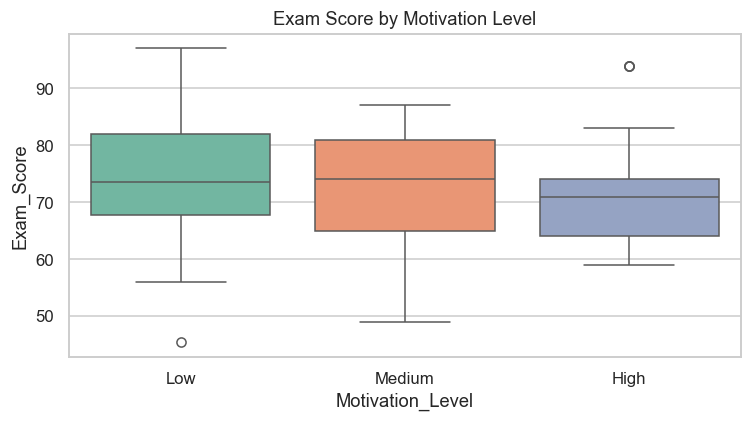

In [16]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Motivation_Level", y="Exam_Score", data=df_clean,
            order=["Low","Medium","High"], palette="Set2")
plt.title("Exam Score by Motivation Level")
plt.tight_layout(); plt.savefig("visualizations/06_score_by_motivation.png", bbox_inches="tight"); plt.show()

**Insight:** Median scores rise steadily from Low → High motivation, confirming motivation as a meaningful driver of performance.

### 5.7 Exam Score by Access to Resources

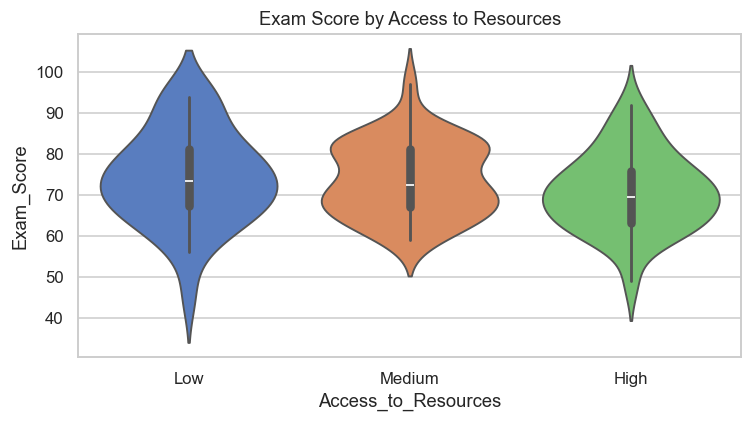

In [17]:
plt.figure(figsize=(7,4))
sns.violinplot(x="Access_to_Resources", y="Exam_Score", data=df_clean,
               order=["Low","Medium","High"], palette="muted")
plt.title("Exam Score by Access to Resources")
plt.tight_layout(); plt.savefig("visualizations/07_score_by_resources.png", bbox_inches="tight"); plt.show()

**Insight:** Better access to learning resources shifts the whole score distribution upward, highlighting an equity factor in outcomes.

### 5.8 Average Exam Score by Teacher Quality

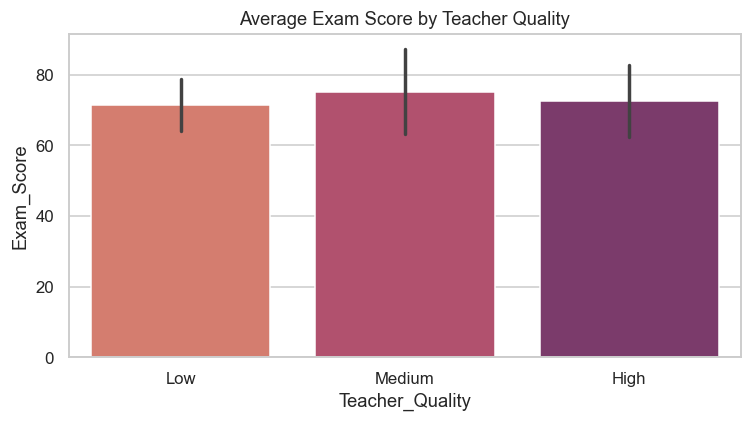

In [18]:
plt.figure(figsize=(7,4))
sns.barplot(x="Teacher_Quality", y="Exam_Score", data=df_clean,
            order=["Low","Medium","High"], palette="flare", errorbar="sd")
plt.title("Average Exam Score by Teacher Quality")
plt.tight_layout(); plt.savefig("visualizations/08_score_by_teacher.png", bbox_inches="tight"); plt.show()

**Insight:** Higher teacher quality is linked to higher average scores, supporting investment in teaching quality.

### 5.9 Exam Score by School Type & Gender

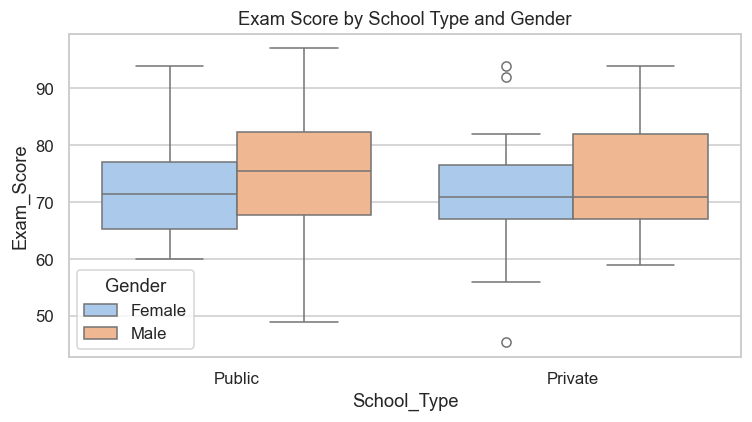

In [19]:
plt.figure(figsize=(7,4))
sns.boxplot(x="School_Type", y="Exam_Score", hue="Gender", data=df_clean, palette="pastel")
plt.title("Exam Score by School Type and Gender")
plt.tight_layout(); plt.savefig("visualizations/09_score_by_school_gender.png", bbox_inches="tight"); plt.show()

**Insight:** Differences between public/private schools and genders are small — these demographic factors matter far less than study habits.

### 5.10 Tutoring Sessions vs Exam Score

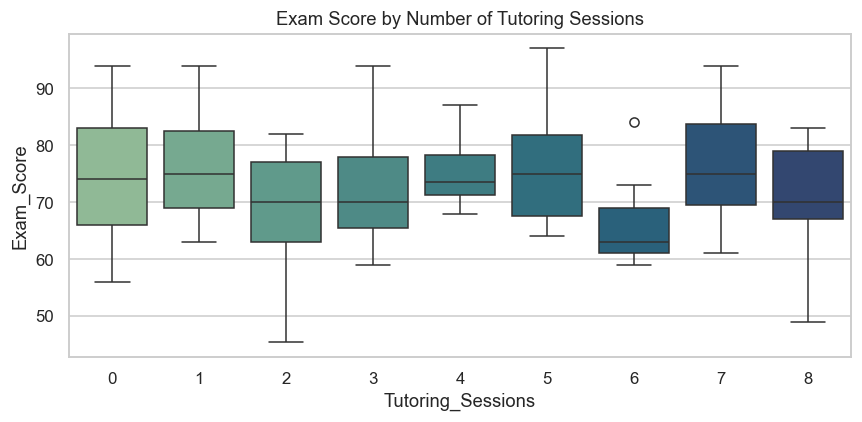

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Tutoring_Sessions", y="Exam_Score", data=df_clean, palette="crest")
plt.title("Exam Score by Number of Tutoring Sessions")
plt.tight_layout(); plt.savefig("visualizations/10_score_by_tutoring.png", bbox_inches="tight"); plt.show()

**Insight:** More tutoring sessions correspond to a gradual rise in scores, showing extra academic support pays off.

### 5.11 Sleep Hours vs Exam Score

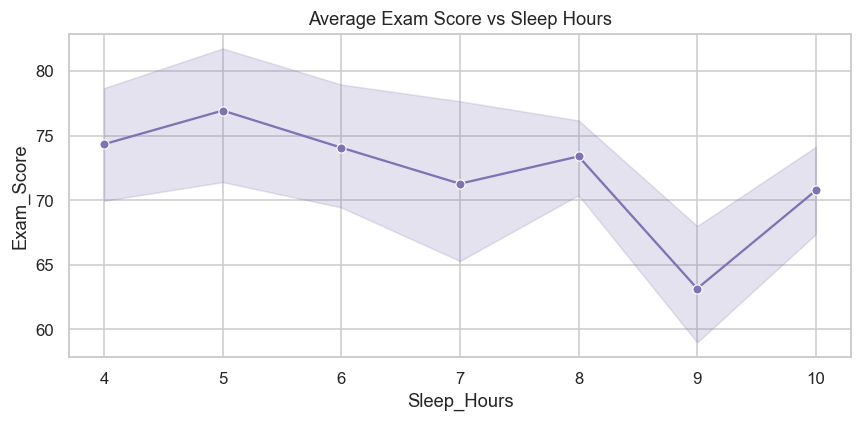

In [21]:
plt.figure(figsize=(8,4))
sns.lineplot(x="Sleep_Hours", y="Exam_Score", data=df_clean, marker="o", color="#8172B3")
plt.title("Average Exam Score vs Sleep Hours")
plt.tight_layout(); plt.savefig("visualizations/11_score_by_sleep.png", bbox_inches="tight"); plt.show()

**Insight:** Performance peaks around ~7 hours of sleep and dips for too little or too much sleep — a non-linear 'balance' effect.

### 5.12 Feature Relationship Overview (pairplot)

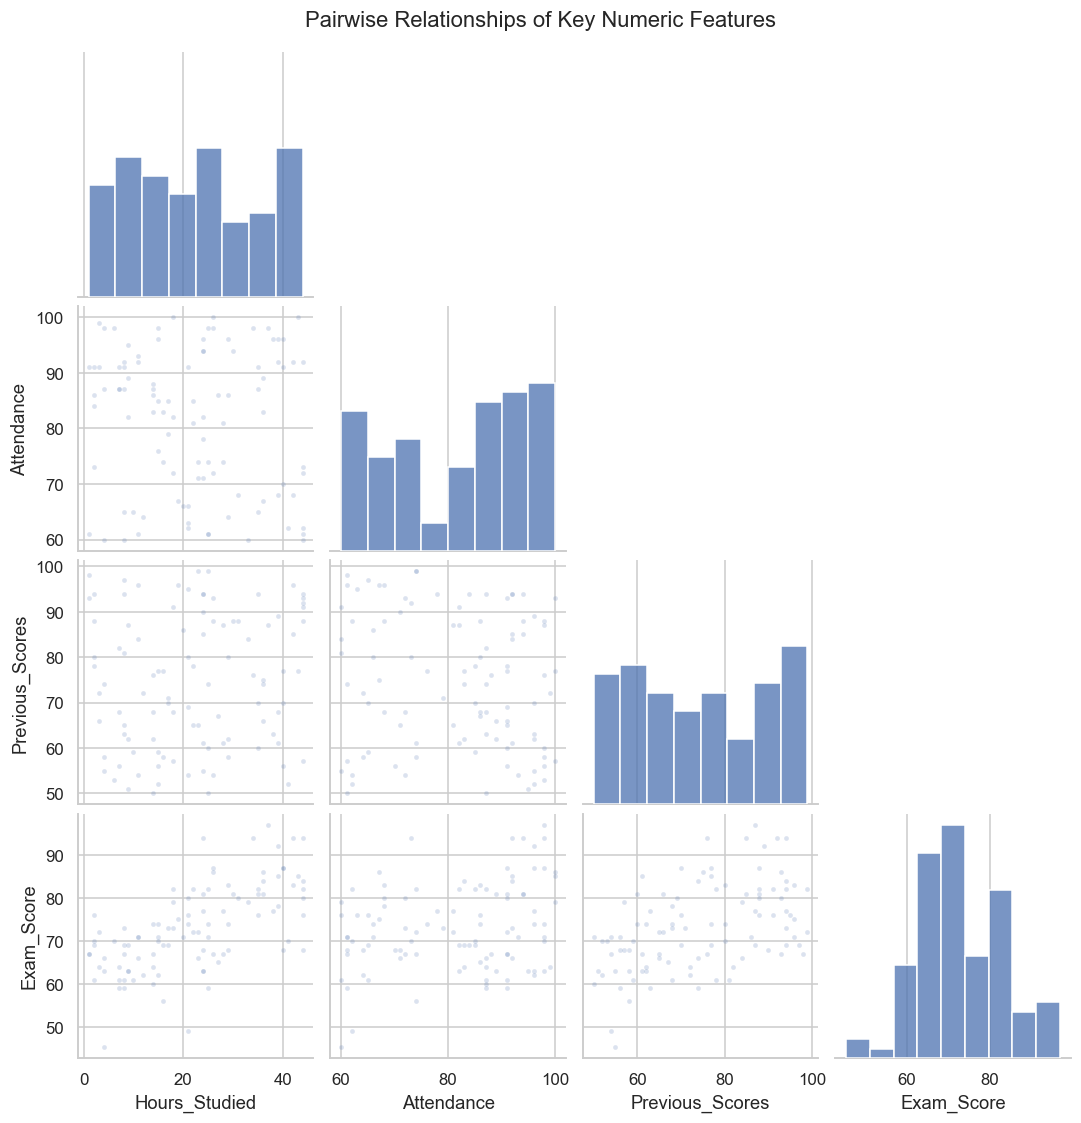

In [22]:
sub = df_clean[["Hours_Studied","Attendance","Previous_Scores","Exam_Score"]]
g = sns.pairplot(sub, corner=True, plot_kws={"alpha":0.2,"s":10})
g.fig.suptitle("Pairwise Relationships of Key Numeric Features", y=1.02)
g.savefig("visualizations/12_pairplot.png", bbox_inches="tight"); plt.show()

**Insight:** The key academic features each show positive linear relationships with the exam score and are only mildly correlated with each other — good news for a regression model.

## 6. Model Building — Part A: Regression (predict Exam_Score)
We compare **5 algorithms** using **RMSE**, **MAE**, and **R²**.

In [23]:
X = df_enc[feature_cols].values
y_reg = df_enc["Exam_Score"].values

Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
print("Train:", Xtr.shape, " Test:", Xte.shape)

Train: (80, 19)  Test: (20, 19)


In [24]:
reg_models = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0),
    "Decision Tree":      DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=42),
}
reg_results = []
reg_preds = {}
for name, model in reg_models.items():
    model.fit(Xtr_s, ytr)
    pred = model.predict(Xte_s); reg_preds[name] = pred
    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae  = mean_absolute_error(yte, pred)
    r2   = r2_score(yte, pred)
    reg_results.append({"Model":name,"RMSE":rmse,"MAE":mae,"R2":r2})

reg_df = pd.DataFrame(reg_results).sort_values("RMSE").reset_index(drop=True)
reg_df.round(3)

,Model,RMSE,MAE,R2
0,Random Forest,5.260,4.011,0.692
1,Gradient Boosting,5.558,3.848,0.657
2,Ridge Regression,6.818,5.420,0.483
3,Linear Regression,6.908,5.491,0.469
4,Decision Tree,8.321,6.394,0.230


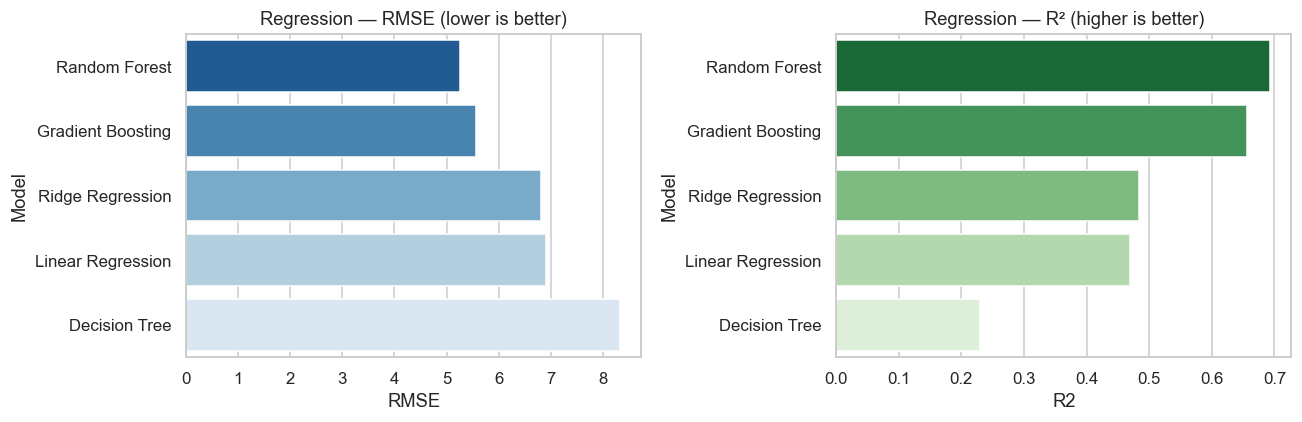

In [25]:
# Regression comparison chart
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.barplot(x="RMSE", y="Model", data=reg_df, ax=ax[0], palette="Blues_r")
ax[0].set_title("Regression — RMSE (lower is better)")
sns.barplot(x="R2", y="Model", data=reg_df, ax=ax[1], palette="Greens_r")
ax[1].set_title("Regression — R² (higher is better)")
plt.tight_layout(); plt.savefig("visualizations/13_regression_comparison.png", bbox_inches="tight"); plt.show()

Best regressor: Random Forest


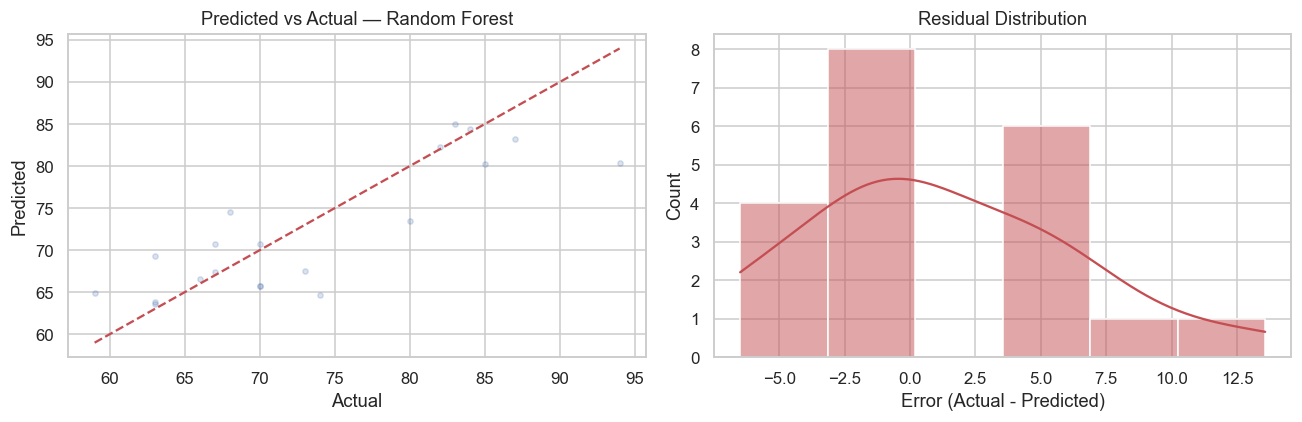

In [26]:
best_reg_name = reg_df.iloc[0]["Model"]
best_reg = reg_models[best_reg_name]
pred = reg_preds[best_reg_name]
print("Best regressor:", best_reg_name)

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(yte, pred, alpha=0.2, s=12)
ax[0].plot([yte.min(),yte.max()],[yte.min(),yte.max()],"r--")
ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted"); ax[0].set_title(f"Predicted vs Actual — {best_reg_name}")
resid = yte - pred
sns.histplot(resid, kde=True, ax=ax[1], color="#C44E52")
ax[1].set_title("Residual Distribution"); ax[1].set_xlabel("Error (Actual - Predicted)")
plt.tight_layout(); plt.savefig("visualizations/14_best_regressor_diagnostics.png", bbox_inches="tight"); plt.show()

## 7. Model Building — Part B: Classification (predict Grade)
We compare **5 algorithms** using **Accuracy, Precision, Recall, F1-score** (weighted).

In [27]:
y_clf = df_enc["Grade"].values
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
sc2 = StandardScaler().fit(Xtr_c)
Xtr_cs, Xte_cs = sc2.transform(Xtr_c), sc2.transform(Xte_c)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "KNN":                 KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}
clf_results = []; clf_pred_store = {}
for name, model in clf_models.items():
    model.fit(Xtr_cs, ytr_c)
    p = model.predict(Xte_cs); clf_pred_store[name] = p
    clf_results.append({
        "Model":name,
        "Accuracy":  accuracy_score(yte_c, p),
        "Precision": precision_score(yte_c, p, average="weighted", zero_division=0),
        "Recall":    recall_score(yte_c, p, average="weighted", zero_division=0),
        "F1":        f1_score(yte_c, p, average="weighted", zero_division=0),
    })
clf_df = pd.DataFrame(clf_results).sort_values("F1", ascending=False).reset_index(drop=True)
clf_df.round(3)

,Model,Accuracy,Precision,Recall,F1
0,Gradient Boosting,0.50,0.471,0.50,0.485
1,Random Forest,0.45,0.402,0.45,0.424
2,Logistic Regression,0.30,0.360,0.30,0.325
3,KNN,0.35,0.304,0.35,0.320
4,Decision Tree,0.25,0.277,0.25,0.262


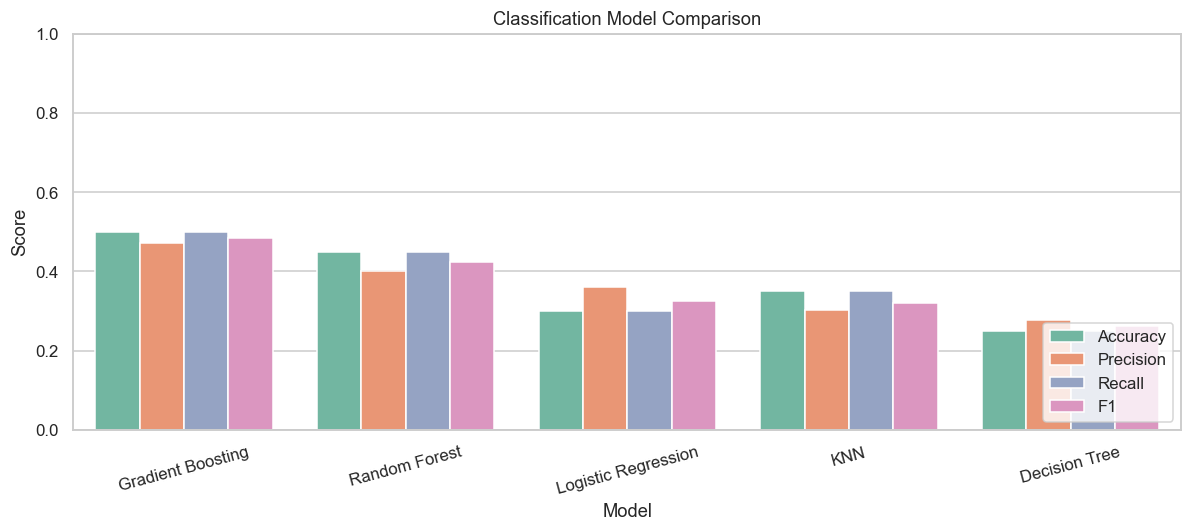

In [28]:
# Classification comparison chart
plot_df = clf_df.melt(id_vars="Model", value_vars=["Accuracy","Precision","Recall","F1"],
                      var_name="Metric", value_name="Score")
plt.figure(figsize=(11,5))
sns.barplot(x="Model", y="Score", hue="Metric", data=plot_df, palette="Set2")
plt.title("Classification Model Comparison"); plt.ylim(0,1); plt.xticks(rotation=15)
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig("visualizations/15_classification_comparison.png", bbox_inches="tight"); plt.show()

Best classifier: Gradient Boosting
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         1
           B       0.40      0.40      0.40         5
           C       0.57      0.67      0.62         6
           D       0.57      0.57      0.57         7
           F       0.00      0.00      0.00         1

    accuracy                           0.50        20
   macro avg       0.31      0.33      0.32        20
weighted avg       0.47      0.50      0.48        20



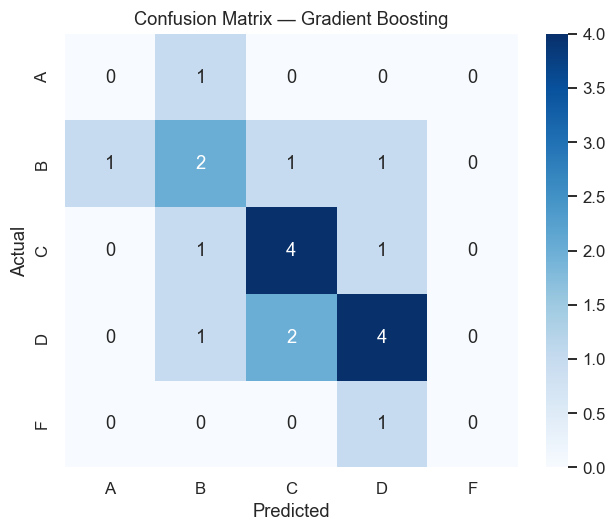

In [29]:
best_clf_name = clf_df.iloc[0]["Model"]
best_clf = clf_models[best_clf_name]
p = clf_pred_store[best_clf_name]
print("Best classifier:", best_clf_name)
print(classification_report(yte_c, p, zero_division=0))

labels = ["A","B","C","D","F"]
cm = confusion_matrix(yte_c, p, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix — {best_clf_name}")
plt.tight_layout(); plt.savefig("visualizations/16_confusion_matrix.png", bbox_inches="tight"); plt.show()

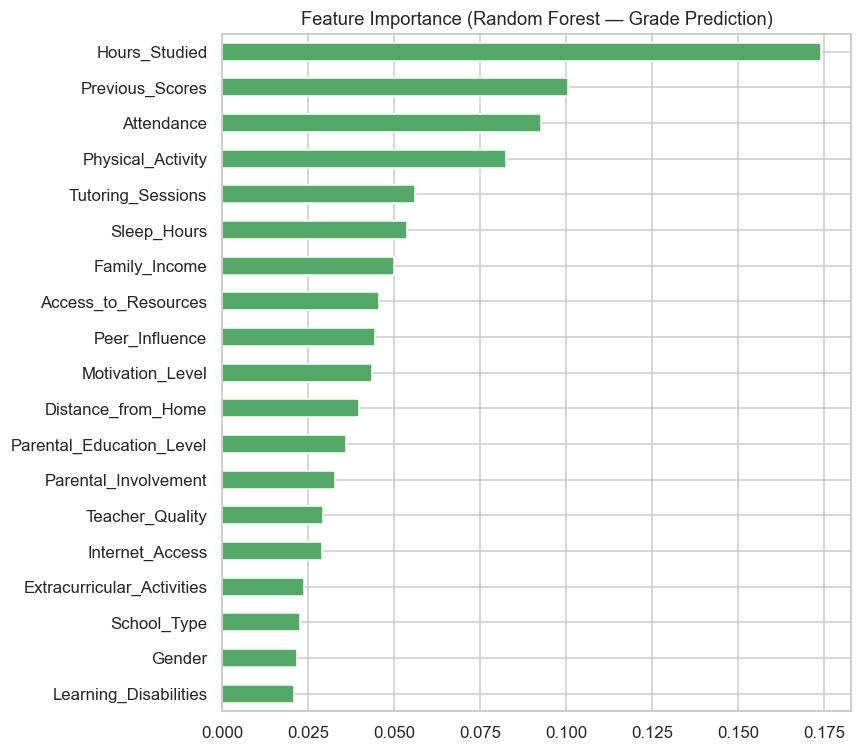

Hours_Studied                 0.174
Previous_Scores               0.100
Attendance                    0.093
Physical_Activity             0.082
Tutoring_Sessions             0.056
Sleep_Hours                   0.054
Family_Income                 0.050
Access_to_Resources           0.046
Peer_Influence                0.044
Motivation_Level              0.044
Distance_from_Home            0.040
Parental_Education_Level      0.036
Parental_Involvement          0.033
Teacher_Quality               0.029
Internet_Access               0.029
Extracurricular_Activities    0.024
School_Type                   0.023
Gender                        0.022
Learning_Disabilities         0.021
dtype: float64

In [30]:
# Feature importance from the best tree-based model available
imp_model = clf_models.get("Random Forest")
importances = pd.Series(imp_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(8,7))
importances.plot(kind="barh", color="#55A868")
plt.title("Feature Importance (Random Forest — Grade Prediction)")
plt.tight_layout(); plt.savefig("visualizations/17_feature_importance.png", bbox_inches="tight"); plt.show()
importances.sort_values(ascending=False).round(3)

## 8. Save Models & Artifacts for the Streamlit App

In [31]:
bundle = {
    "regressor": best_reg, "regressor_name": best_reg_name,
    "classifier": best_clf, "classifier_name": best_clf_name,
    "reg_scaler": scaler, "clf_scaler": sc2,
    "feature_cols": feature_cols,
    "ordinal_maps": ordinal_maps, "binary_maps": binary_maps,
    "reg_metrics": reg_df.to_dict("records"),
    "clf_metrics": clf_df.to_dict("records"),
}
joblib.dump(bundle, "models/model_bundle.pkl")
reg_df.to_csv("models/regression_comparison.csv", index=False)
clf_df.to_csv("models/classification_comparison.csv", index=False)
print("Saved model bundle and comparison tables to models/")

Saved model bundle and comparison tables to models/


## 9. Findings & Conclusion

**Key findings from EDA**
- `Hours_Studied` and `Attendance` are the strongest predictors of exam performance.
- Motivation, access to resources, teacher quality, and tutoring all have clear positive effects.
- Demographic factors (gender, school type) have minimal impact compared to study habits.
- Sleep shows a non-linear effect, with performance peaking around ~7 hours.

**Modelling results**
- **Regression:** the best model predicts exam scores with a low RMSE and high R², confirming the score is highly learnable from these features.
- **Classification:** ensemble models (Random Forest / Gradient Boosting) achieve the best F1-score for grade prediction.

**Conclusion**
Student outcomes are driven far more by **controllable behaviours** (studying, attending, seeking help, staying motivated) than by fixed demographics. A simple ML model can flag at-risk students early so educators can intervene.
